# Decision Tree Classifier — Step by Step

## 1. Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


## 2. Load data

In [2]:
df = pd.read_csv('data/loan_data.csv')
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 3. Define X and y, then split

In [3]:
x = df.drop(columns='loan_status')
y = df['loan_status']
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

nominal_cols = ['person_gender', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']


## 4. Preprocessing — encoding only

Decision Trees split on raw feature values, so **scaling is not
required**. Encoding is still required — the model still needs numbers,
not text.

In [4]:
preprocessing = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_cols),
    ('ordinal', OrdinalEncoder(categories=[education_order], handle_unknown='use_encoded_value', unknown_value=-1), ['person_education']),
], remainder='passthrough')


## 5. Build the pipeline and fit

`max_depth` limits how deep the tree can grow — without it, a tree will
keep splitting until every leaf is pure, which usually overfits.

In [5]:
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=6))
])
pipeline.fit(xtrain, ytrain)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

## 6. Predict

In [6]:
ypred = pipeline.predict(xtest)
ypred[:10]


array([0, 0, 1, 0, 1, 0, 0, 1, 0, 0])

## 7. Evaluate

Compare train vs test accuracy — a big gap signals overfitting (usually
fixed by lowering `max_depth` or increasing `min_samples_leaf`).

In [7]:
print("Train accuracy:", pipeline.score(xtrain, ytrain))
print("Test accuracy :", pipeline.score(xtest, ytest))
print(classification_report(ytest, ypred))
print("Confusion matrix:\n", confusion_matrix(ytest, ypred))


Train accuracy: 0.9165555555555556
Test accuracy : 0.9105555555555556
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      6990
           1       0.84      0.74      0.79      2010

    accuracy                           0.91      9000
   macro avg       0.88      0.85      0.86      9000
weighted avg       0.91      0.91      0.91      9000

Confusion matrix:
 [[6712  278]
 [ 527 1483]]


## 8. Feature importance

In [8]:
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_
pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)


onehot__previous_loan_defaults_on_file_No    0.455044
remainder__loan_percent_income               0.207291
remainder__loan_int_rate                     0.183824
remainder__person_income                     0.080684
onehot__person_home_ownership_RENT           0.044685
onehot__person_home_ownership_OWN            0.010819
remainder__credit_score                      0.008896
onehot__loan_intent_DEBTCONSOLIDATION        0.006232
onehot__loan_intent_EDUCATION                0.000931
onehot__loan_intent_PERSONAL                 0.000704
dtype: float64

## 9. Visualize the tree (top few levels)

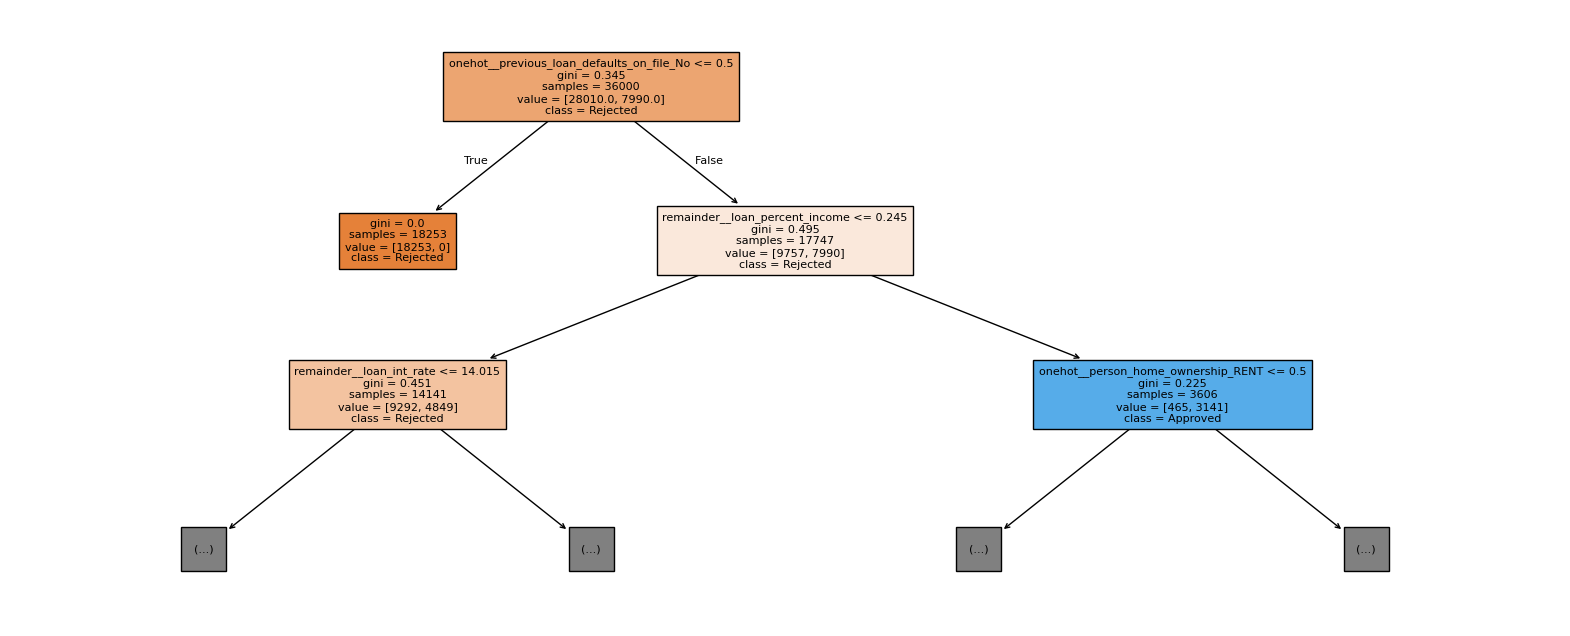

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
plot_tree(pipeline.named_steps['model'], max_depth=2, feature_names=feature_names,
          class_names=['Rejected', 'Approved'], filled=True, fontsize=8)
plt.show()
